In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization, Lambda,
    Concatenate, Reshape, Add)
from tensorflow.keras.models import Model
import pandas as pd
import random

In [2]:
# -----------------------------
# Reproducibility
# -----------------------------
os.environ['PYTHONHASHSEED'] = str(42)
tf.config.experimental.enable_op_determinism()
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

**Function**

In [3]:
def random_batch(X, batch_size=32):
    idx = np.random.randint(len(X), size=batch_size)
    return X[idx]

In [4]:
def SER_calculator(input_msg, msg):
    true_idx = tf.argmax(input_msg, axis=1, output_type=tf.int32)
    pred_idx = tf.argmax(msg,       axis=1, output_type=tf.int32)
    ser = tf.reduce_mean(tf.cast(tf.not_equal(true_idx, pred_idx), tf.float32))
    return ser

In [5]:
def SNR_to_noise(SNR_db, n=1):
    SNR = 10**(SNR_db/10)
    noise_std = 1.0 / np.sqrt(SNR * n)
    return noise_std

In [6]:
def complex_mul(a, b):
        ar, ai = a[:,0,:], a[:,1,:]
        br, bi = b[:,0,:], b[:,1,:]
        yr = ar * br - ai * bi
        yi = ar * bi + ai * br
        return tf.stack([yr, yi], axis=1)

def complex_conj(h):
    return tf.stack([h[:,0,:], -h[:,1,:]], axis=1)

def complex_abs2(h):
    return tf.reduce_sum(tf.square(h), axis=1, keepdims=True)

In [7]:
# -----------------------------
# Helper: unique variable list
# -----------------------------
def unique_trainable_vars(*models_or_layers):
    out = []
    seen = set()
    for m in models_or_layers:
        for v in m.trainable_variables:
            vid = id(v)
            if vid not in seen:
                out.append(v)
                seen.add(vid)
    return out

**Autoencoder Fucntions**

In [8]:
# -----------------------------
# Autoencoder: Encoder
# -----------------------------
def build_encoder(name_prefix, M, n):
    input_signal = Input(shape=(M,), name=f"{name_prefix}_Input")
    x = Dense(M, activation='relu', name=f"{name_prefix}_ReLU")(input_signal)
    x = Dense(2 * n, name=f"{name_prefix}_Dense")(x)
    x = Reshape((2, n), name=f"{name_prefix}_Reshape")(x)
    # x = Lambda(lambda x: tf.sqrt(tf.cast(n, tf.float32)) * tf.math.l2_normalize(x, axis=[1,2]), name=f"{name_prefix}_Norm")(x)
    x = Lambda(lambda x: tf.math.l2_normalize(x, axis=[1]), name=f"{name_prefix}_Norm")(x)  # Dimension power = 1, test 2
    return Model(inputs=input_signal, outputs=x, name=f"{name_prefix}")

In [9]:
# -----------------------------
# Channel layers
# -----------------------------
def generate_shadowed_rician_H(batch_size, b=0.126, m=10.1,omega=0.835, r_hat=1.0, phi=0.0): # Average shadowing (AS)
    K = omega / (2.0 * b)
    p = np.sqrt(K / (1 + K)) * r_hat * np.cos(phi)
    q = np.sqrt(K / (1 + K)) * r_hat * np.sin(phi)
    sigma = r_hat / np.sqrt(2.0 * (1.0 + K))

    xi = np.sqrt(np.random.gamma(shape=m, scale=1.0/m, size=batch_size))
    X = np.random.normal(loc=0.0, scale=sigma, size=batch_size) + xi * p
    Y = np.random.normal(loc=0.0, scale=sigma, size=batch_size) + xi * q

    return X.astype(np.float32), Y.astype(np.float32)

def Shadowed_rician_fading_layer(name=None):
    def fading(x, h_real, h_imag):
        x_real = x[:, 0, :]
        x_imag = x[:, 1, :]
        y_real = h_real * x_real - h_imag * x_imag
        y_imag = h_real * x_imag + h_imag * x_real
        return tf.stack([y_real, y_imag], axis=1)
    return Lambda(lambda inputs: fading(inputs[0], inputs[1], inputs[2]), name=name)

def awgn_channel_layer(noise_std, name=None):
    noise_std = tf.convert_to_tensor(noise_std, dtype=tf.float32)
    def add_awgn(x):
        x_real = x[:, 0, :]
        x_imag = x[:, 1, :]
        s = noise_std / tf.sqrt(tf.constant(2.0, dtype=tf.float32))
        n_real = tf.random.normal(tf.shape(x_real), stddev=s)
        n_imag = tf.random.normal(tf.shape(x_imag), stddev=s)
        return tf.stack([x_real + n_real, x_imag + n_imag], axis=1)
    return Lambda(add_awgn, name=name)

In [10]:
def build_decoder(name_prefix, M, n):
    # 입력
    y_input   = Input(shape=(2, n), name="Rx_Input")     # 수신 신호
    h_real    = Input(shape=(1,),  name="h_real")        # 자기 채널
    h_imag    = Input(shape=(1,),  name="h_imag")
    h_if_real = Input(shape=(1,),  name="h_if_real")     # 간섭 채널
    h_if_imag = Input(shape=(1,),  name="h_if_imag")

    y_flat  = Lambda(lambda y: tf.reshape(y, [-1, 2*n]), name="Flatten")(y_input)   # [B, 2n]
    h_feat  = Lambda(lambda t: tf.concat(t, axis=1), name="Hcat")([h_real, h_imag, h_if_real, h_if_imag])
    x = Lambda(lambda t: tf.concat(t, axis=1), name="Merge")([y_flat, h_feat])

    x = keras.layers.Dense(512, activation='relu', name="FC1")(x)
    x = keras.layers.LayerNormalization()(x)

    x = keras.layers.Dense(256, activation='relu', name="FC2")(x)
    x = keras.layers.LayerNormalization()(x)

    x = Dense(M, activation='softmax', name="Out")(x)
    return keras.Model(inputs=[y_input, h_real, h_imag, h_if_real, h_if_imag], outputs=x, name=f"{name_prefix}")

In [11]:
# -----------------------------
# Parameters
# -----------------------------
NOMA_SNR = 3
M1 = 8; n1 = 2; training_SNR1 = 20                         # GEO 1
M2 = 4; n2 = 2; training_SNR2 = training_SNR1 - NOMA_SNR   # GEO 2

# TRAINING PARAMETERS
# sample_size = 300_000; N_test = 500_000; n_epochs = 10; batch_size = 512        # Low epochs
sample_size = 500_000; N_test = 1_000_000; n_epochs = 25; batch_size = 512        # Middle epochs
# sample_size = 300_000; N_test = 1_000_000; n_epochs = 50; batch_size = 512      # High epochs

messages_1 = np.random.randint(M1, size= sample_size)
messages_2 = np.random.randint(M2, size= sample_size)

h_real_1, h_imag_1 = generate_shadowed_rician_H(sample_size)
h_real_2, h_imag_2 = generate_shadowed_rician_H(sample_size)

one_hot_encoder1 = OneHotEncoder(categories=[range(M1)], sparse_output=False)
one_hot_encoder2 = OneHotEncoder(categories=[range(M2)], sparse_output=False)

data_oneH_1 = one_hot_encoder1.fit_transform(messages_1.reshape(-1,1))
data_oneH_2 = one_hot_encoder2.fit_transform(messages_2.reshape(-1,1))

noise_std1 = SNR_to_noise(training_SNR1, n=n1)
noise_std2 = SNR_to_noise(training_SNR2, n=n2)

In [12]:
# -----------------------------
# Build Autoencoder
# -----------------------------
# Input
input1 = Input(shape=(M1,), name="Tx1_Input")
input2 = Input(shape=(M2,), name="Tx2_Input")

h_real_input1 = Input(shape=(1,), name="H1_real")
h_imag_input1 = Input(shape=(1,), name="H1_imag")
h_real_input2 = Input(shape=(1,), name="H2_real")
h_imag_input2 = Input(shape=(1,), name="H2_imag")

# Encoder
encoder1_layer = build_encoder('Encoder1', M1, n1)
encoder2_layer = build_encoder('Encoder2', M2, n2)
encoder1 = encoder1_layer(input1)
encoder2 = encoder2_layer(input2)

# Channel
faded1 = Shadowed_rician_fading_layer(name="Fading1_Layer")([encoder1, h_real_input1, h_imag_input1])
faded2 = Shadowed_rician_fading_layer(name="Fading2_Layer")([encoder2, h_real_input2, h_imag_input2])

sum1 = Add(name="Sum12")([faded1, faded2])
sum2 = Add(name="Sum21")([faded2, faded1])

channel1 = awgn_channel_layer(noise_std1, name="AWGN1_layer")(sum1)
channel2 = awgn_channel_layer(noise_std2, name="AWGN2_layer")(sum2)

# Decoder
decoder1_layer = build_decoder('Decoder1', M1, n1)
decoder2_layer = build_decoder('Decoder2', M2, n2)
decoder1 = decoder1_layer([channel1, h_real_input1, h_imag_input1, h_real_input2, h_imag_input2])
decoder2 = decoder2_layer([channel2, h_real_input2, h_imag_input2, h_real_input1, h_imag_input1])

# Autoencoder Models
autoencoder1 = Model(
    inputs=[input1, input2, h_real_input1, h_imag_input1, h_real_input2, h_imag_input2], 
    outputs=decoder1, name="Autoencoder1")
autoencoder2 = Model(
    inputs=[input2, input1, h_real_input2, h_imag_input2, h_real_input1, h_imag_input1],
    outputs=decoder2, name="Autoencoder2")

In [13]:
# -----------------------------
# Plot helpers
# -----------------------------
def constellation_plot(M1, M2, n1, n2, save_path=None):

    inp1 = np.eye(M1, dtype=np.float32)
    inp2 = np.eye(M2, dtype=np.float32)

    out1 = encoder1_layer(inp1)
    out2 = encoder2_layer(inp2)

    coding1 = out1.numpy()
    coding2 = out2.numpy()

    n1_eff = coding1.shape[2]
    n2_eff = coding2.shape[2]
    max_dim = max(n1_eff, n2_eff)

    markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

    fig, axes = plt.subplots(1, max_dim + 1, figsize=(5*(max_dim + 1), 5))

    if max_dim + 1 == 1:
        axes = [axes]

    for d in range(max_dim):
        ax = axes[d]

        if d < n1_eff:
            ax.plot(
                coding1[:, 0, d], coding1[:, 1, d],
                marker=markers[d], markersize=5,
                linestyle='None', color='blue',label=f'GEO1 dim{d}'
            )

        if d < n2_eff:
            ax.plot(
                coding2[:, 0, d], coding2[:, 1, d],
                marker=markers[d], markersize=5,
                linestyle='None', color='red', label=f'GEO2 dim{d}'
            )

        ax.set_title(f'Dimension {d}')
        ax.set_xlabel("In-Phase")
        ax.set_ylabel("Quadrature")
        ax.grid(True)
        ax.set_xlim(-2, 2)
        ax.set_ylim(-2, 2)
        ax.legend()

    ax_all = axes[max_dim]

    for d in range(max_dim):

        if d < n1_eff:
            ax_all.plot(
                coding1[:, 0, d], coding1[:, 1, d],
                marker=markers[d], markersize=3,
                linestyle='None', color='blue', label=f'GEO1 dim{d}'
            )

        if d < n2_eff:
            ax_all.plot(
                coding2[:, 0, d], coding2[:, 1, d],
                marker=markers[d], markersize=3,
                linestyle='None', color='red', label=f'GEO2 dim{d}'
            )

    ax_all.set_title("All Dimensions")
    ax_all.set_xlabel("In-Phase")
    ax_all.set_ylabel("Quadrature")
    ax_all.grid(True)
    ax_all.set_xlim(-2, 2)
    ax_all.set_ylim(-2, 2)
    ax_all.legend(fontsize=8)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()



def plot_epoch(epoch, n_epochs, epoch_loss, plot_encoding):
    el = float(epoch_loss.numpy() if hasattr(epoch_loss, "numpy") else epoch_loss)
    print(f'Epoch: {epoch}/{n_epochs}, Loss(avg): {el:.5f}')
    if plot_encoding:
        constellation_plot(M1, M2, n1, n2)


def save_constellation_to_csv(encoder1, encoder2, M1, M2, n1, n2, path, tag1, tag2):
    inp1 = np.eye(M1, dtype=np.float32)
    inp2 = np.eye(M2, dtype=np.float32)

    out1 = encoder1(inp1).numpy()  # Shape: (M1, 2, n1)
    out2 = encoder2(inp2).numpy()  # Shape: (M2, 2, n2)

    data1 = np.transpose(out1, (0, 2, 1)).reshape(M1, -1)
    columns1 = [f'dim{i}_{ax}' for i in range(n1) for ax in ['real', 'imag']]
    df1 = pd.DataFrame(data1, columns=columns1)
    df1['Transmitter'] = 'TX1'
    df1['Symbol_Index'] = np.arange(M1)

    data2 = np.transpose(out2, (0, 2, 1)).reshape(M2, -1)
    columns2 = [f'dim{i}_{ax}' for i in range(n2) for ax in ['real', 'imag']]
    df2 = pd.DataFrame(data2, columns=columns2)
    df2['Transmitter'] = 'TX2'
    df2['Symbol_Index'] = np.arange(M2)

    combined_df = pd.concat([df1, df2], ignore_index=True)

    id_cols = ['Transmitter', 'Symbol_Index']
    data_cols = [col for col in combined_df.columns if col not in id_cols]
    combined_df = combined_df[id_cols + data_cols]
    
    csv_path = os.path.join(path, f"{tag1}_{tag2}Dim.csv")
    combined_df.to_csv(csv_path, index=False, float_format='%.8f')
    print(f"Saved combined constellation data to: {csv_path}")

**Simulation and Train Function**

In [14]:
# -----------------------------
# Train
# -----------------------------
def train_start(n_epochs=5, n_steps=20, batch_size=100, plot_encoding=True, only_decoder=False,loss_fn=None, optimizer=None):

    if only_decoder:
        var_list = unique_trainable_vars(decoder1_layer, decoder2_layer)
    else:
        var_list = unique_trainable_vars(encoder1_layer, encoder2_layer, decoder1_layer, decoder2_layer)

    for epoch in range(1, n_epochs + 1):
        epoch_mean = keras.metrics.Mean()

        for step in range(1, n_steps + 1):
            # Batch 데이터 준비
            X_batch_1 = tf.convert_to_tensor(random_batch(data_oneH_1, batch_size), dtype=tf.float32)
            X_batch_2 = tf.convert_to_tensor(random_batch(data_oneH_2, batch_size), dtype=tf.float32)
            h_real_batch_1 = tf.convert_to_tensor(random_batch(h_real_1, batch_size).reshape(-1, 1), dtype=tf.float32)
            h_imag_batch_1 = tf.convert_to_tensor(random_batch(h_imag_1, batch_size).reshape(-1, 1), dtype=tf.float32)
            h_real_batch_2 = tf.convert_to_tensor(random_batch(h_real_2, batch_size).reshape(-1, 1), dtype=tf.float32)
            h_imag_batch_2 = tf.convert_to_tensor(random_batch(h_imag_2, batch_size).reshape(-1, 1), dtype=tf.float32)

            with tf.GradientTape() as tape:
                y_pred_1 = autoencoder1([X_batch_1, X_batch_2, h_real_batch_1, h_imag_batch_1, h_real_batch_2, h_imag_batch_2], training=True)
                y_pred_2 = autoencoder2([X_batch_2, X_batch_1, h_real_batch_2, h_imag_batch_2, h_real_batch_1, h_imag_batch_1], training=True)

                # # Cross-entropy loss - Type 1
                loss_1 = tf.reduce_mean(loss_fn(X_batch_1, y_pred_1))
                loss_2 = tf.reduce_mean(loss_fn(X_batch_2, y_pred_2))
                total_loss = loss_1 + loss_2

                # # Cross-entropy loss - Type 2
                # alpha = 0.5
                # loss_1 = tf.reduce_mean(loss_fn(X_batch_1, y_pred_1))
                # loss_2 = tf.reduce_mean(loss_fn(X_batch_2, y_pred_2))
                # total_loss = alpha * loss_1 + (1.0 - alpha) * loss_2

            grads = tape.gradient(total_loss, var_list)
            optimizer.apply_gradients(zip(grads, var_list))

            epoch_mean.update_state(total_loss)

        plot_epoch(epoch, n_epochs, epoch_mean.result(), plot_encoding)

In [15]:
# -----------------------------
# Test
# -----------------------------
def Test_AE(data1, data2, SNR_range=None, NOMA_SNR=3):
    if SNR_range is None:
        SNR_range = np.linspace(0, 20, 11)
    SNR_range = np.asarray(SNR_range, dtype=float)
    SNR_range1 = SNR_range
    SNR_range2 = SNR_range - NOMA_SNR
    
    SER_transmitter1 = np.empty_like(SNR_range1, dtype=np.float32)
    SER_transmitter2 = np.empty_like(SNR_range2, dtype=np.float32)
    
    H_test_1_real, H_test_1_imag = generate_shadowed_rician_H(len(data1))
    H_test_2_real, H_test_2_imag = generate_shadowed_rician_H(len(data2))
    
    H1r = tf.convert_to_tensor(H_test_1_real.reshape(-1, 1), dtype=tf.float32)
    H1i = tf.convert_to_tensor(H_test_1_imag.reshape(-1, 1), dtype=tf.float32)
    H2r = tf.convert_to_tensor(H_test_2_real.reshape(-1, 1), dtype=tf.float32)
    H2i = tf.convert_to_tensor(H_test_2_imag.reshape(-1, 1), dtype=tf.float32)

    encoder1 = encoder1_layer(data1)
    encoder2 = encoder2_layer(data2)
    
    fade_layer1 = Shadowed_rician_fading_layer(name=None)
    fade_layer2 = Shadowed_rician_fading_layer(name=None)
    faded1 = fade_layer1([encoder1, H1r, H1i])
    faded2 = fade_layer2([encoder2, H2r, H2i])
    
    for i, (snr1, snr2) in enumerate(zip(SNR_range1, SNR_range2)):
        sum1 = faded1 + faded2
        sum2 = faded2 + faded1
        
        channel1 = awgn_channel_layer(SNR_to_noise(snr1, n=n1), name=None)(sum1)
        channel2 = awgn_channel_layer(SNR_to_noise(snr2, n=n2), name=None)(sum2)
        
        decoder1 = decoder1_layer([channel1, H1r, H1i, H2r, H2i], training=False)
        decoder2 = decoder2_layer([channel2, H2r, H2i, H1r, H1i], training=False)
        
        SER_transmitter1[i] = SER_calculator(data1, decoder1).numpy()
        SER_transmitter2[i] = SER_calculator(data2, decoder2).numpy()
        
    return (SNR_range1, SER_transmitter1), (SNR_range2, SER_transmitter2)

**Train Function**

In [16]:
# -----------------------------
# Train setting
# -----------------------------
test_msg1 = np.random.randint(M1, size=N_test)
test_msg2 = np.random.randint(M2, size=N_test)

one_hot_encoder1 = OneHotEncoder(sparse_output=False, categories = [range(M1)])
one_hot_encoder2 = OneHotEncoder(sparse_output=False, categories = [range(M2)])
data_normal1 = one_hot_encoder1.fit_transform(test_msg1.reshape(-1,1))
data_normal2 = one_hot_encoder2.fit_transform(test_msg2.reshape(-1,1))

**Train Start**

Epoch: 1/25, Loss(avg): 0.18410


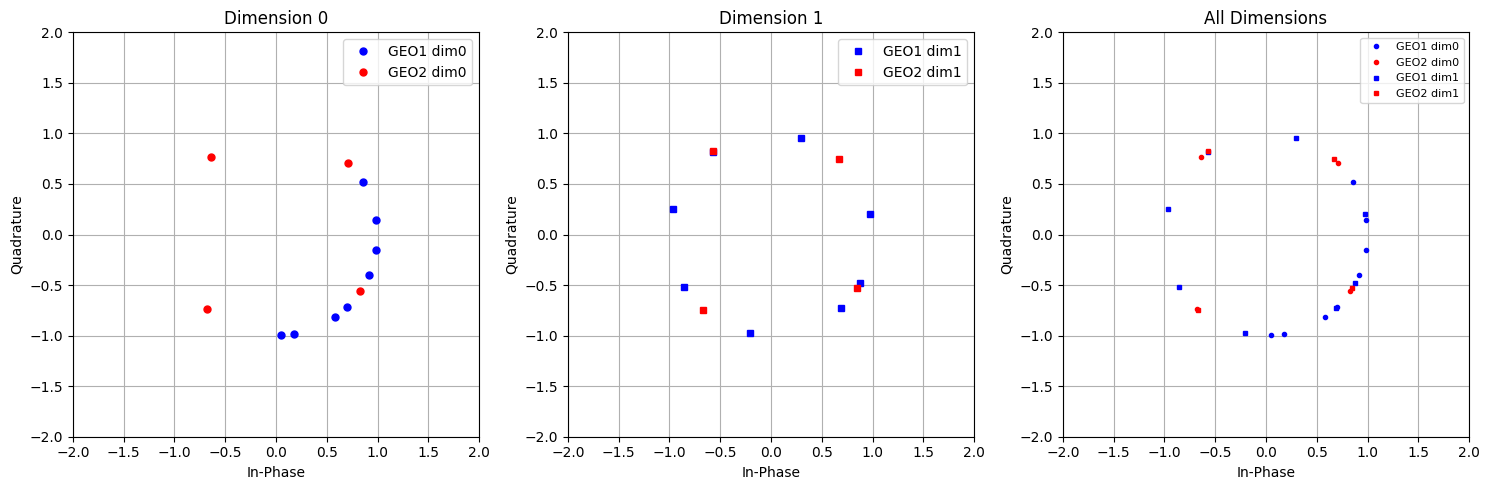

Epoch: 2/25, Loss(avg): 0.04986


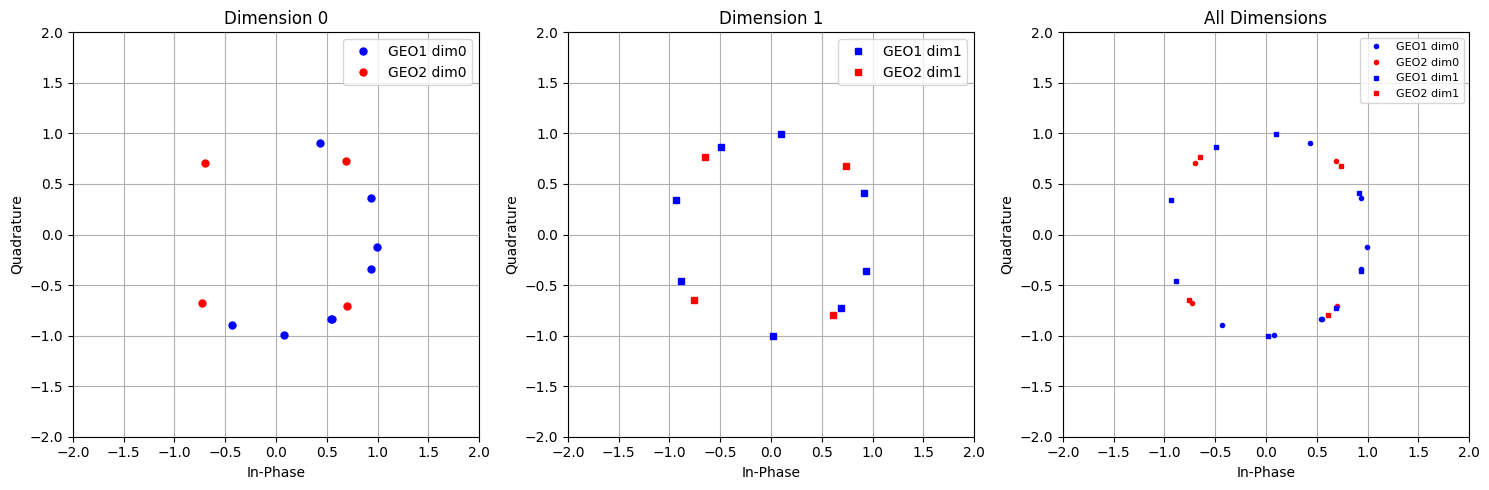

Epoch: 3/25, Loss(avg): 0.04012


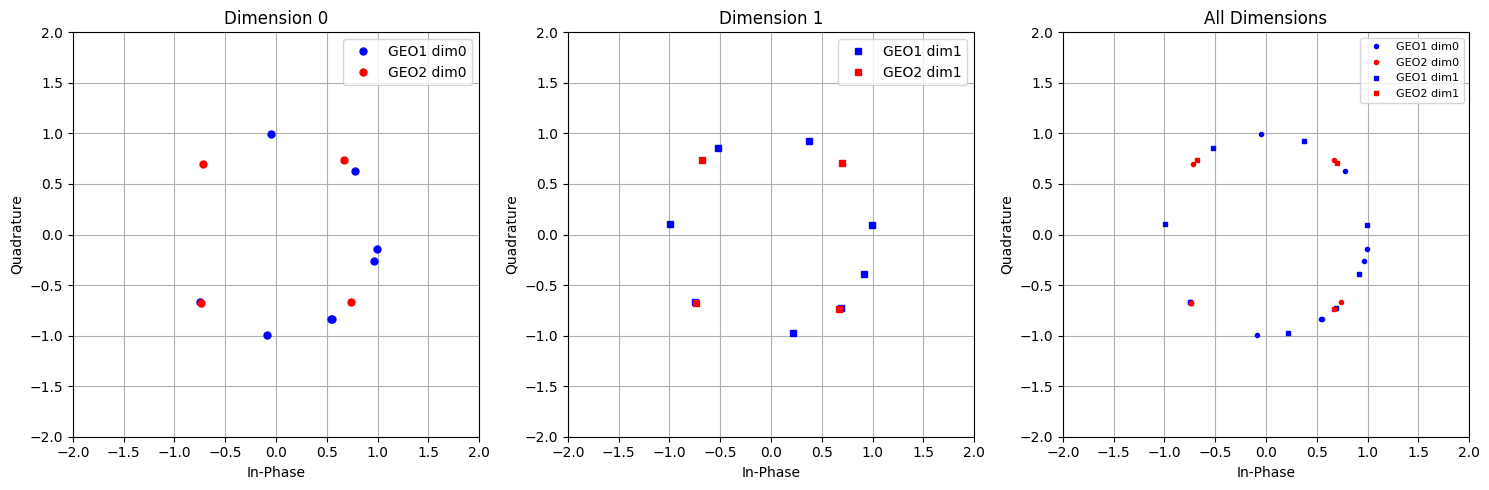

Epoch: 4/25, Loss(avg): 0.03402


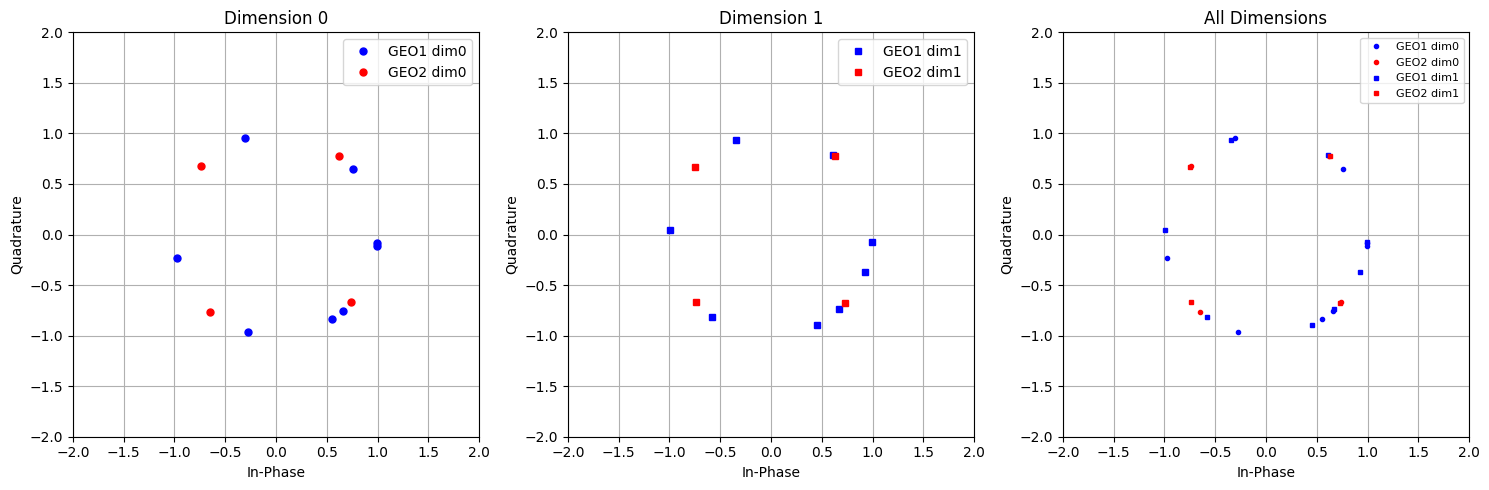

Epoch: 5/25, Loss(avg): 0.03178


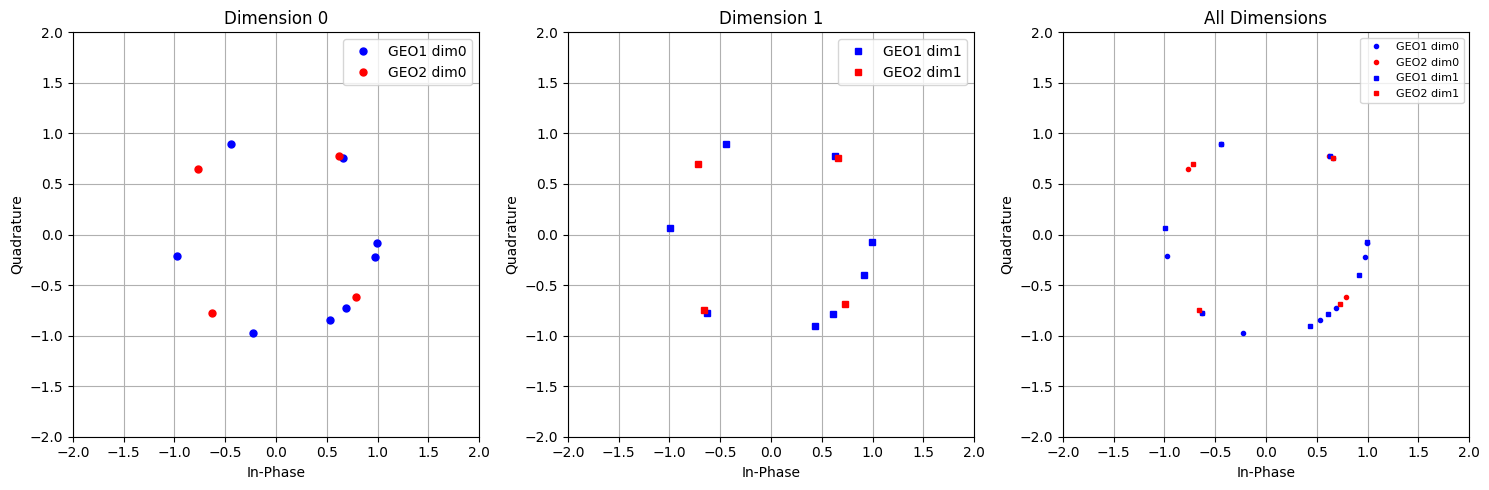

Epoch: 6/25, Loss(avg): 0.02958


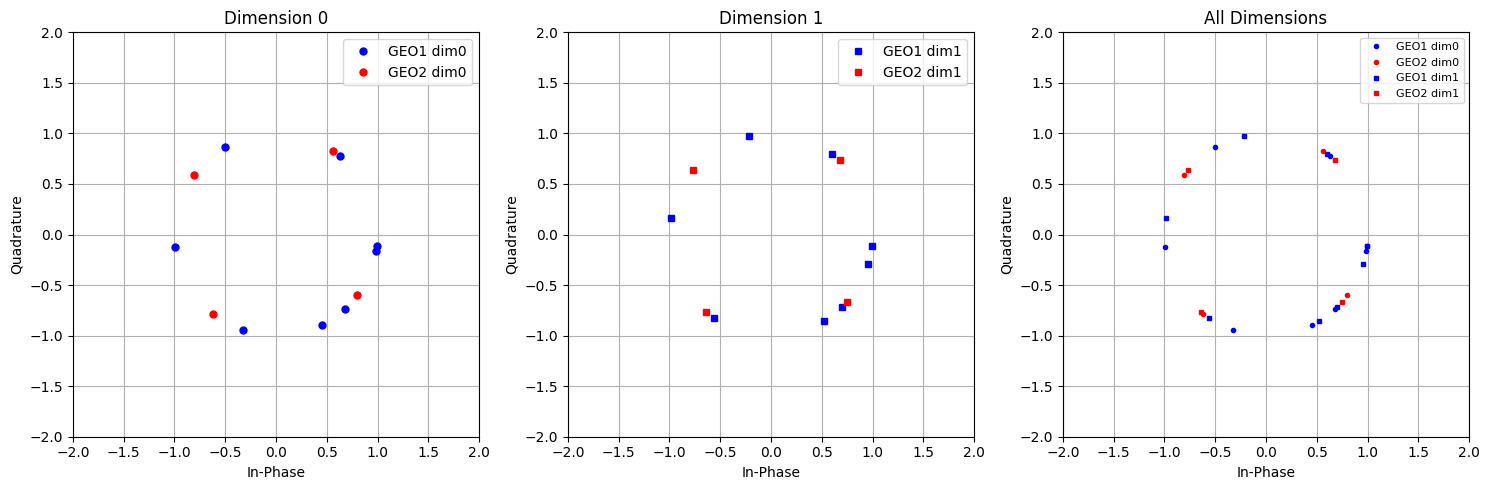

Epoch: 7/25, Loss(avg): 0.02697


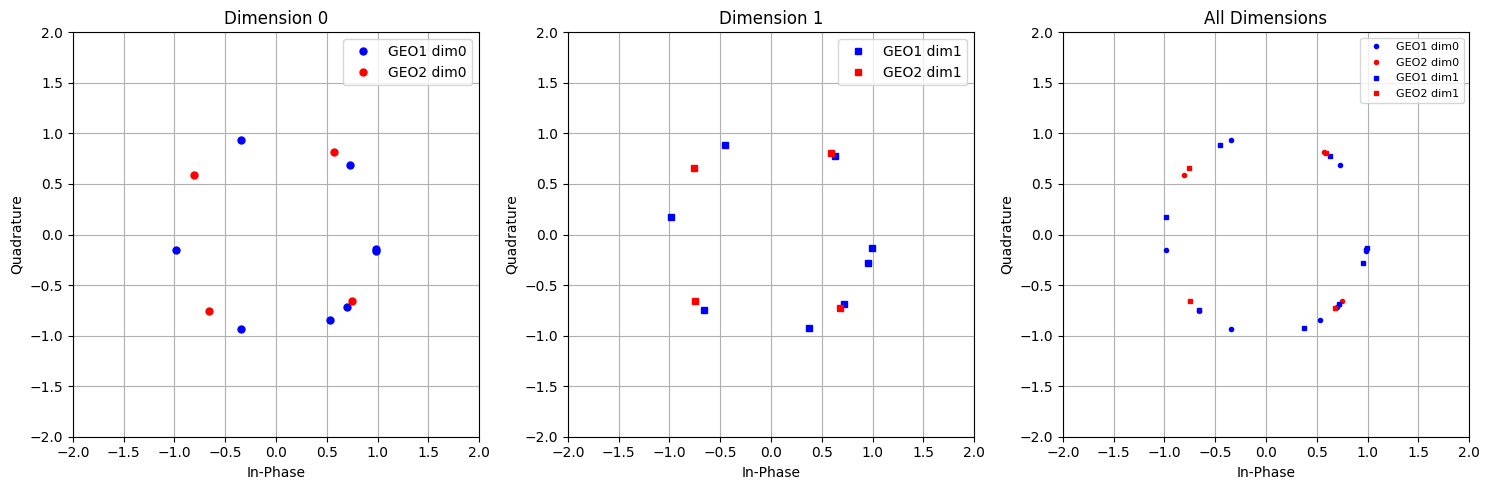

Epoch: 8/25, Loss(avg): 0.02727


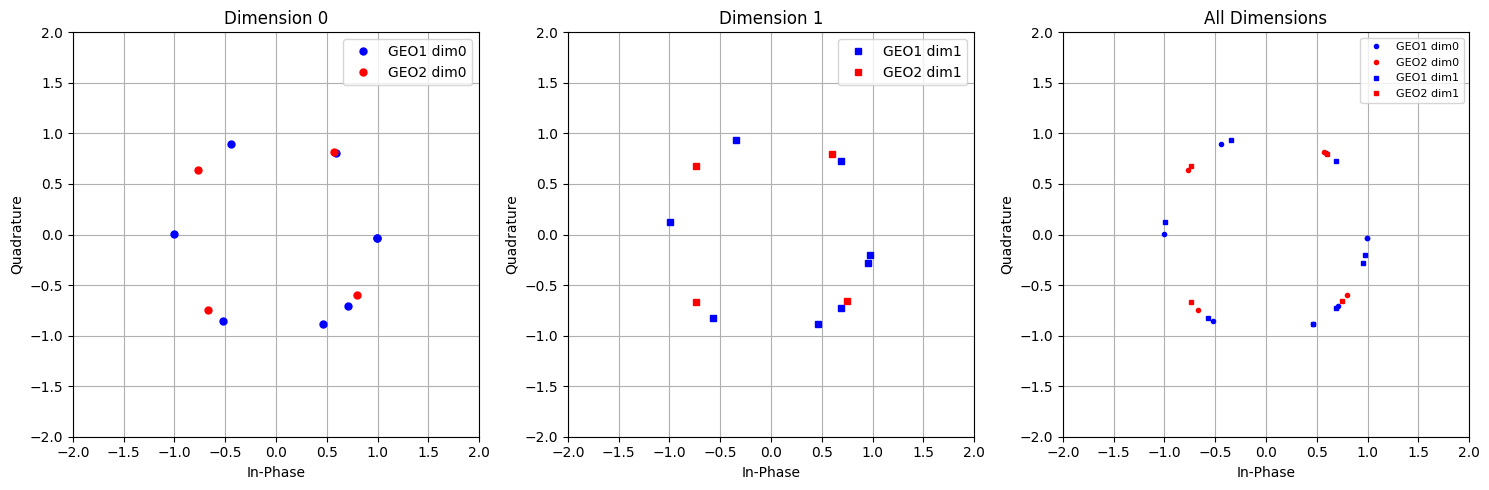

Epoch: 9/25, Loss(avg): 0.02680


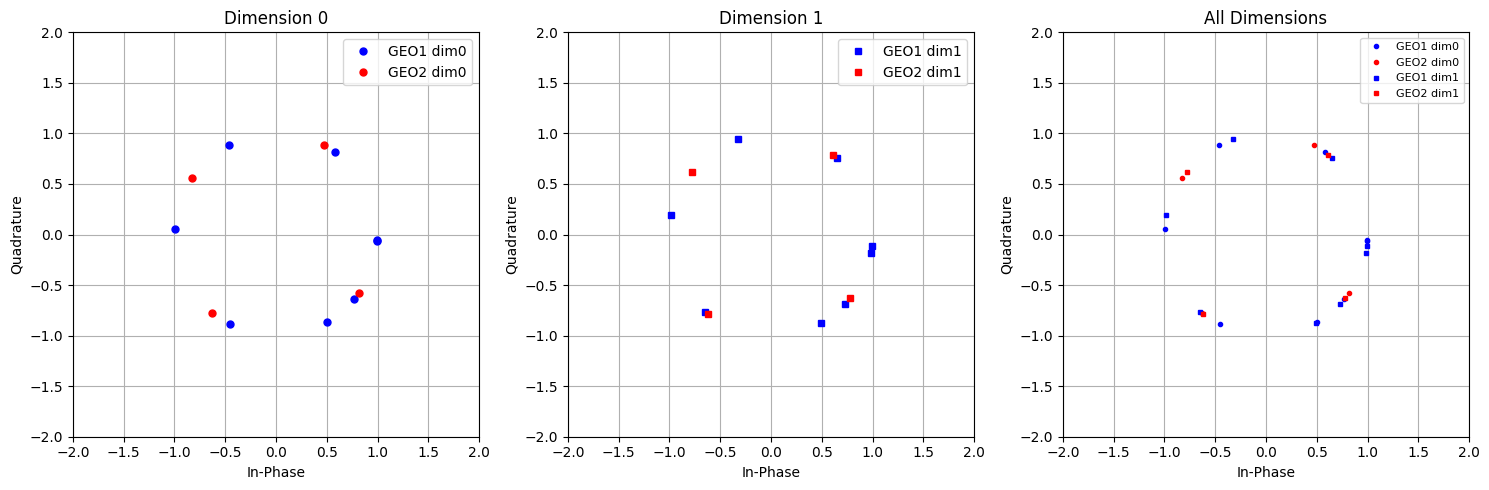

Epoch: 10/25, Loss(avg): 0.02548


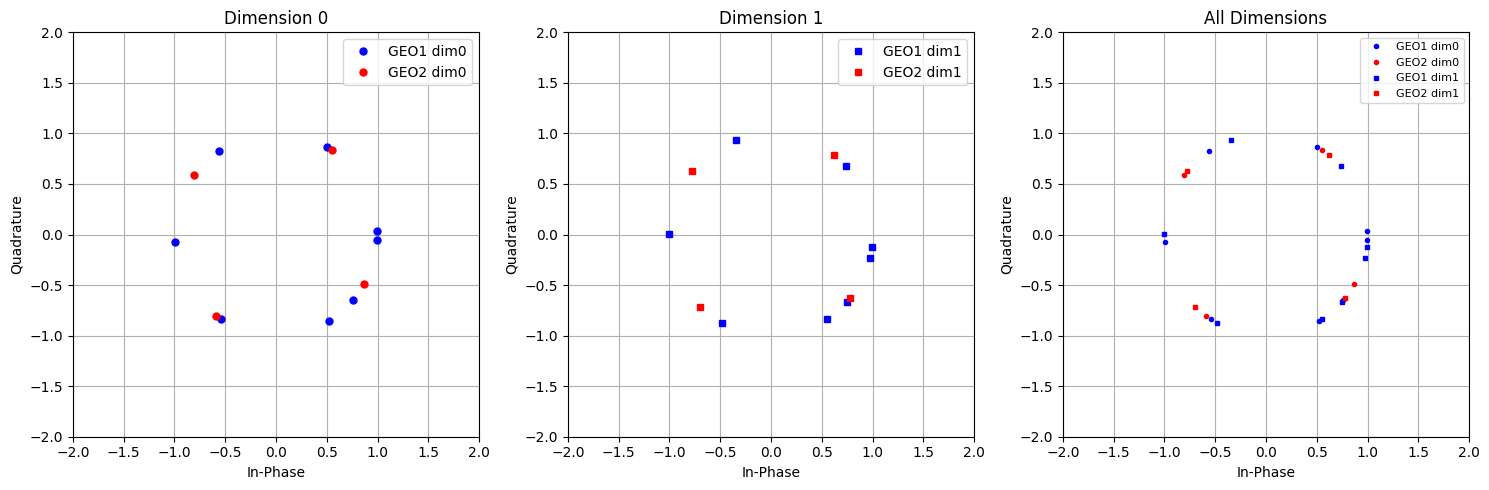

Epoch: 11/25, Loss(avg): 0.02275


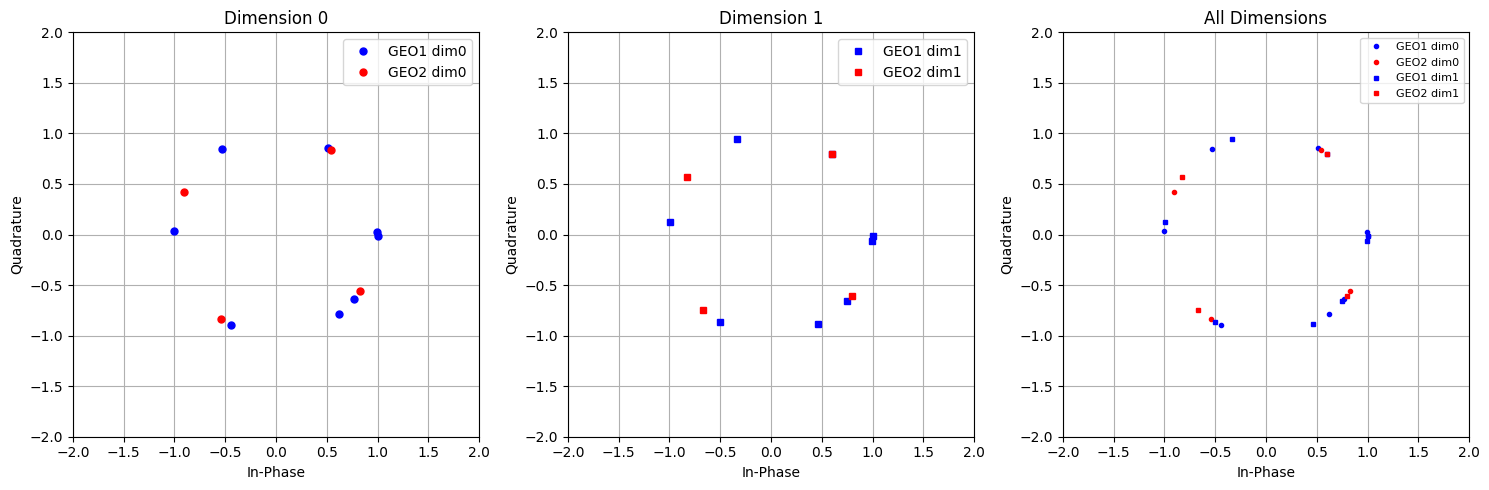

Epoch: 12/25, Loss(avg): 0.02321


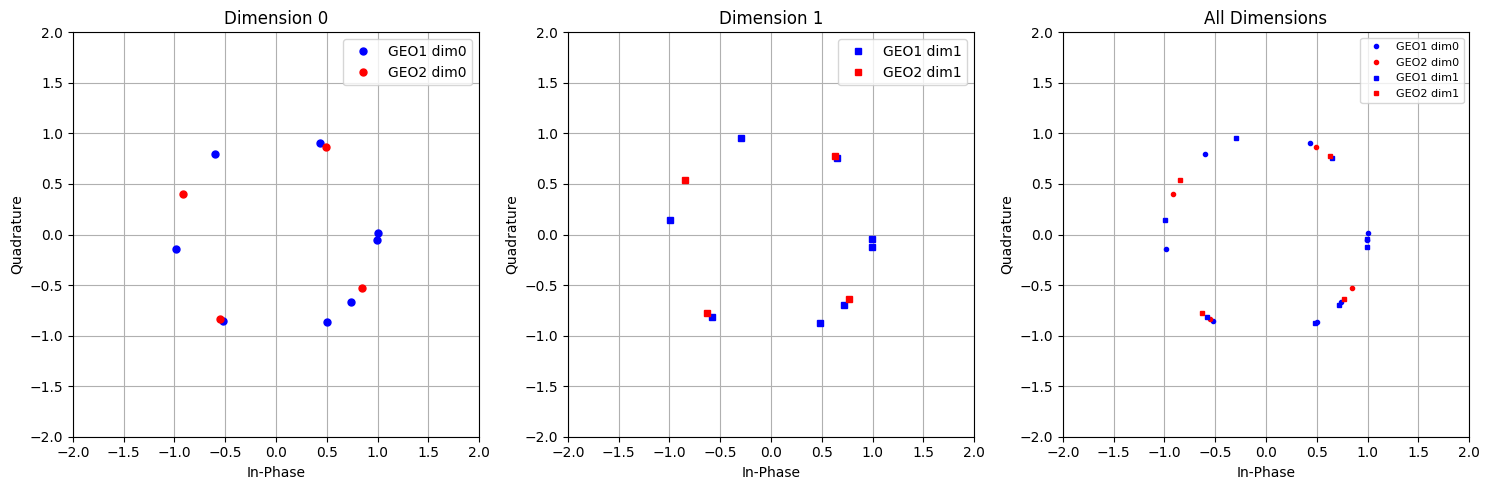

Epoch: 13/25, Loss(avg): 0.02236


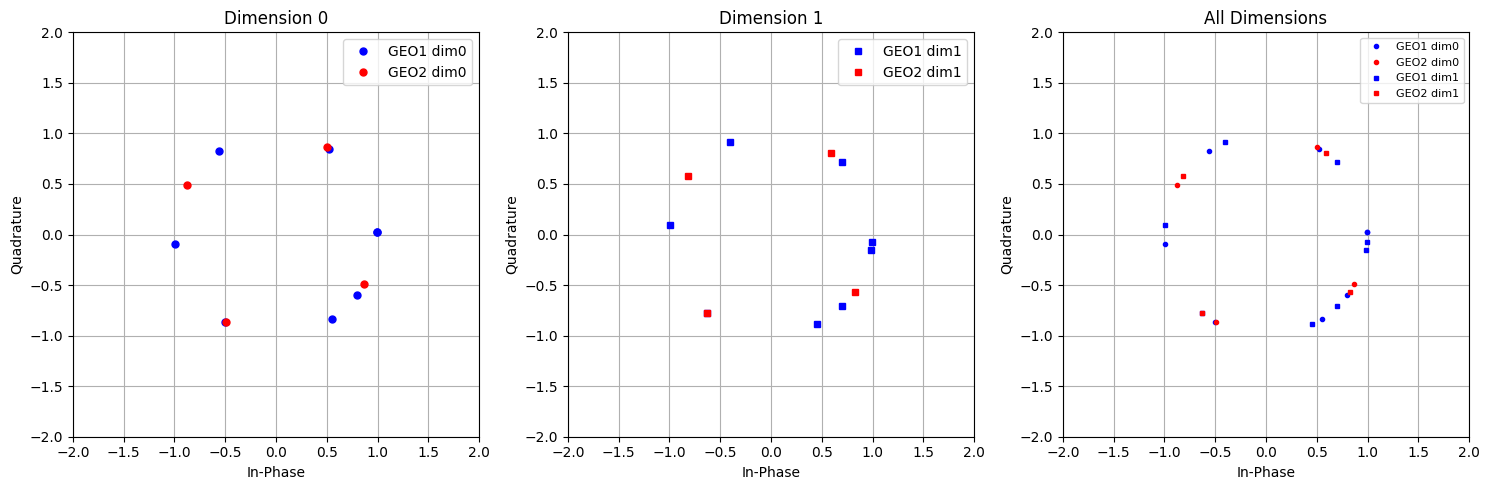

Epoch: 14/25, Loss(avg): 0.02052


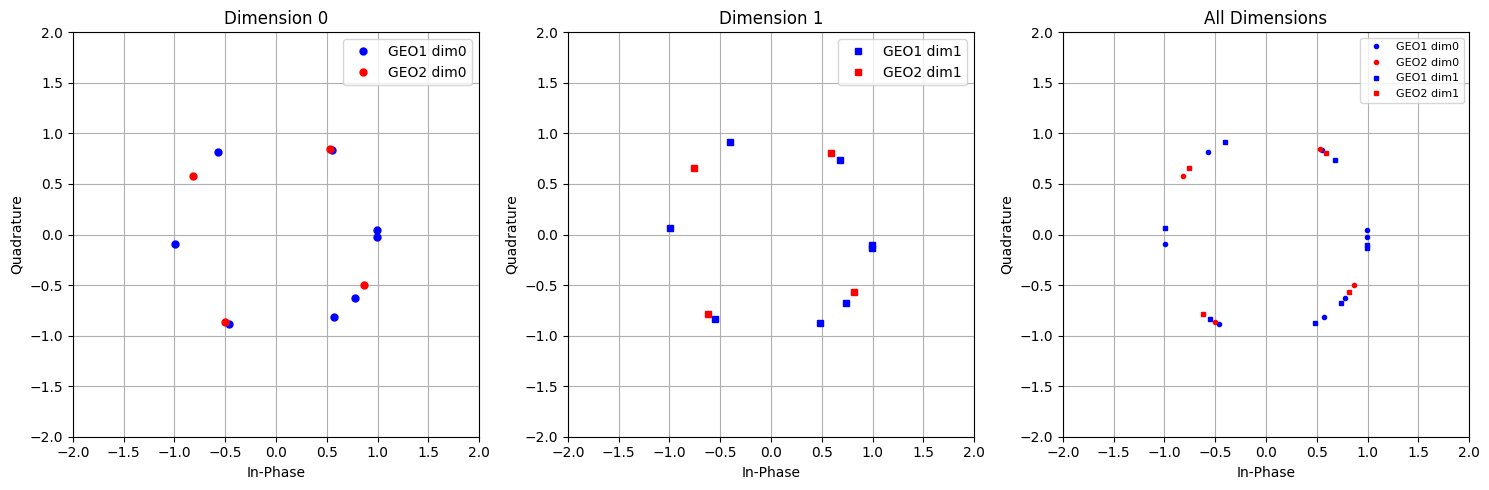

Epoch: 15/25, Loss(avg): 0.02225


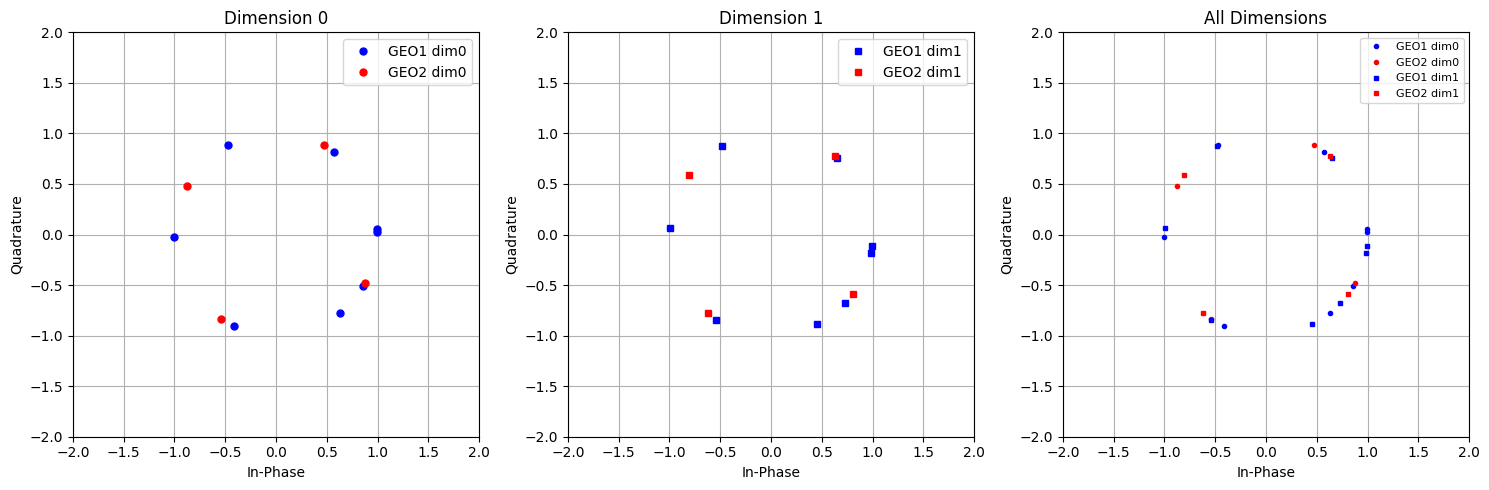

Epoch: 16/25, Loss(avg): 0.02083


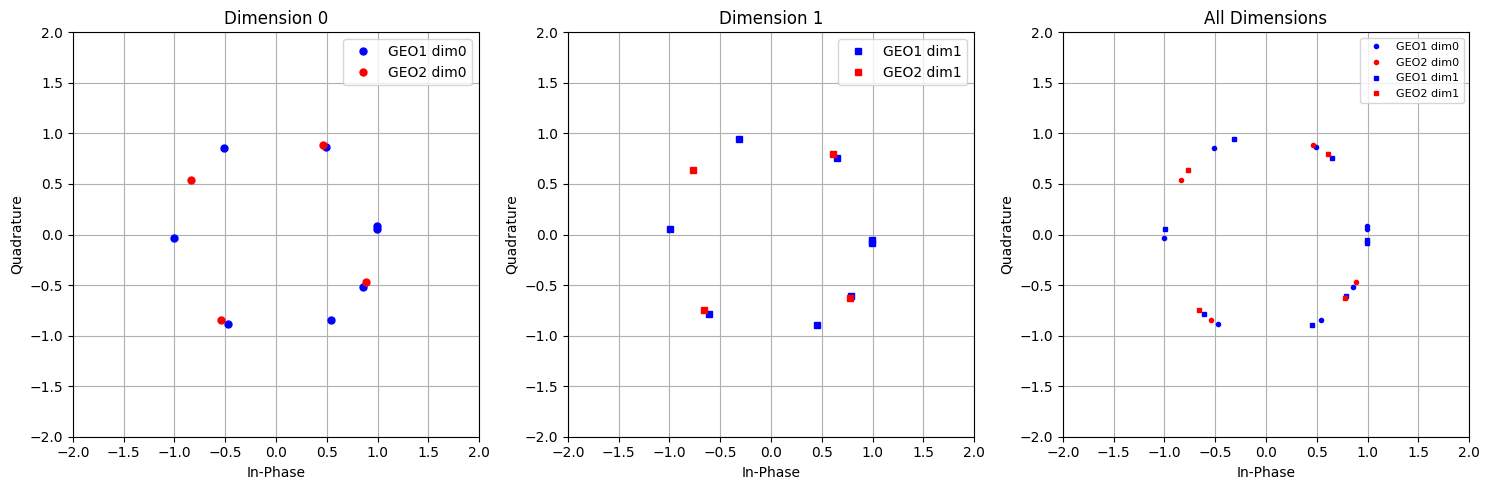

Epoch: 17/25, Loss(avg): 0.02086


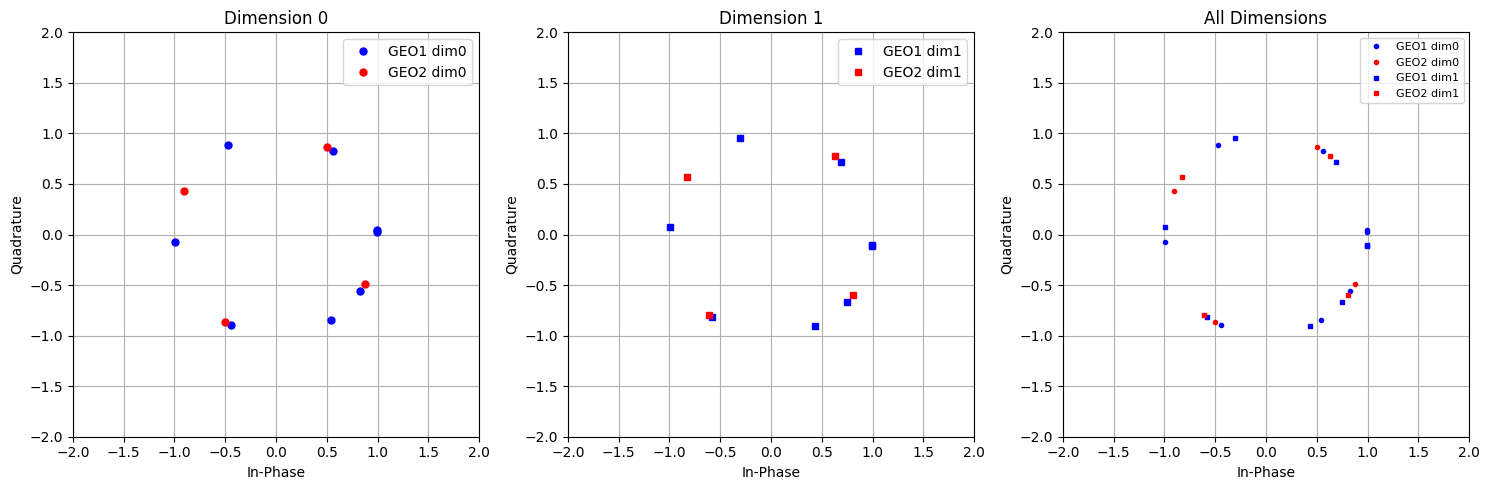

Epoch: 18/25, Loss(avg): 0.02060


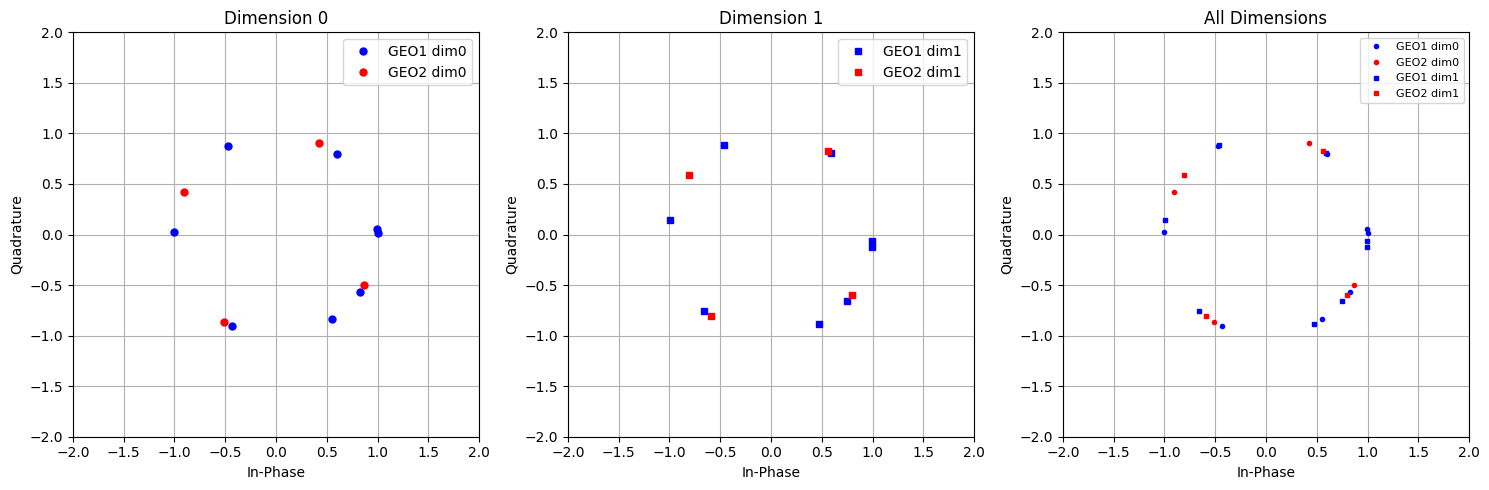

Epoch: 19/25, Loss(avg): 0.01878


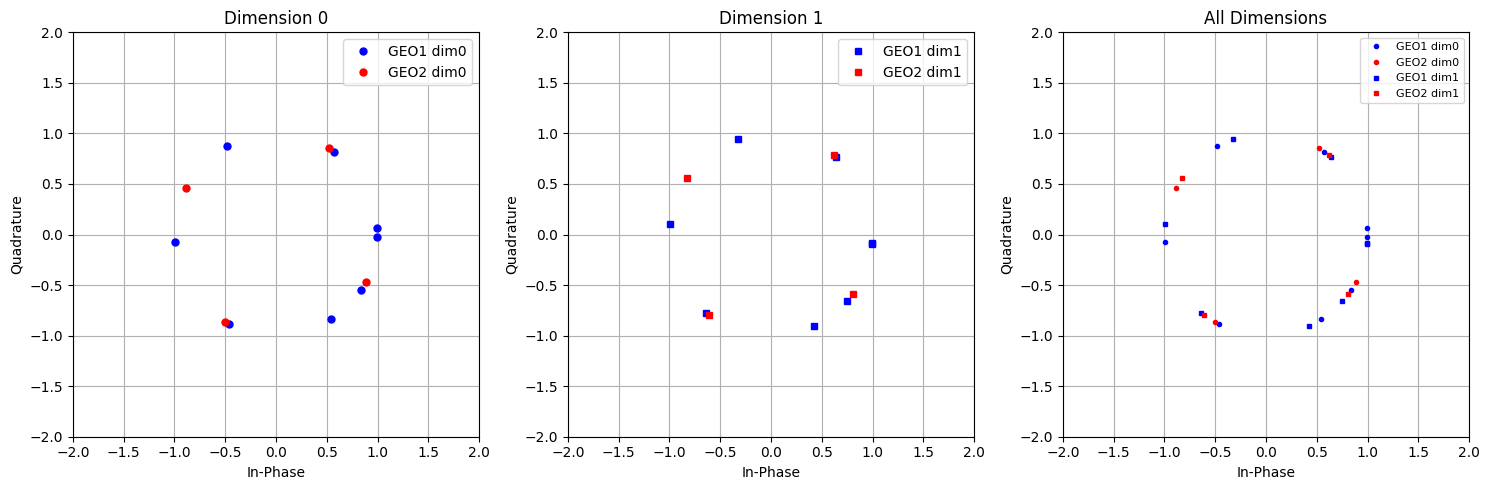

Epoch: 20/25, Loss(avg): 0.02010


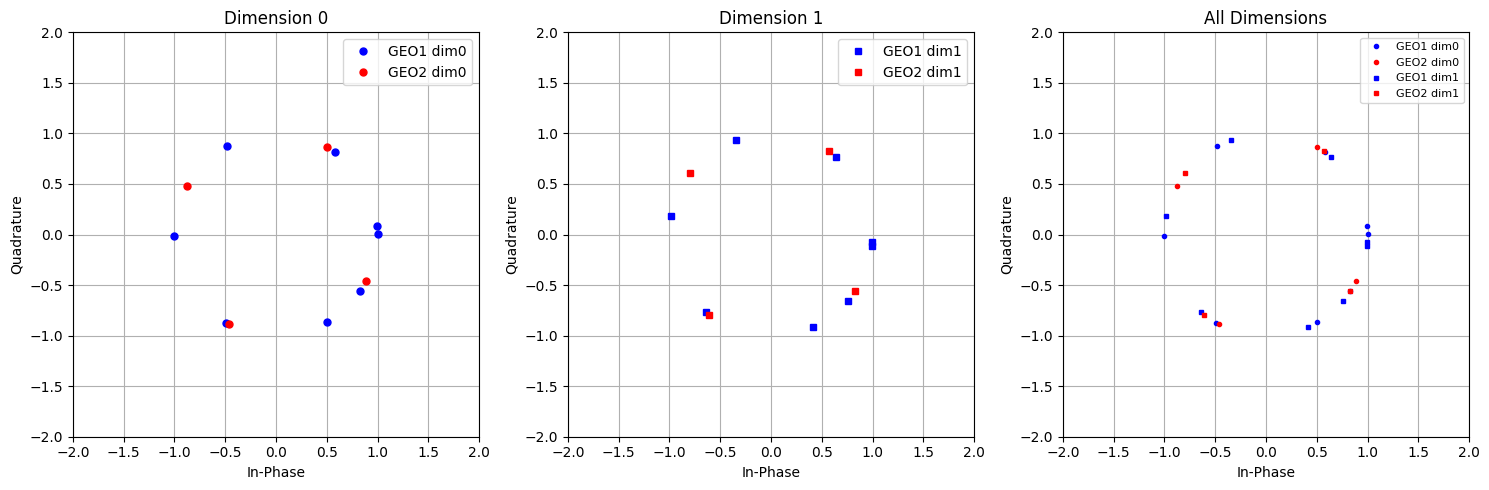

Epoch: 21/25, Loss(avg): 0.01878


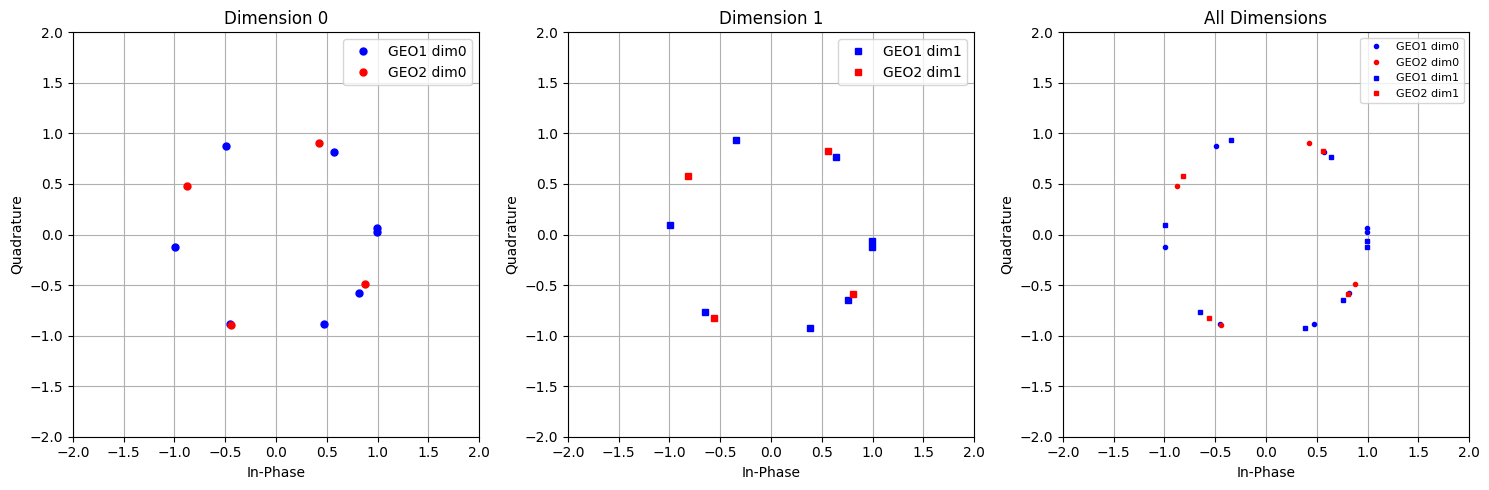

Epoch: 22/25, Loss(avg): 0.01960


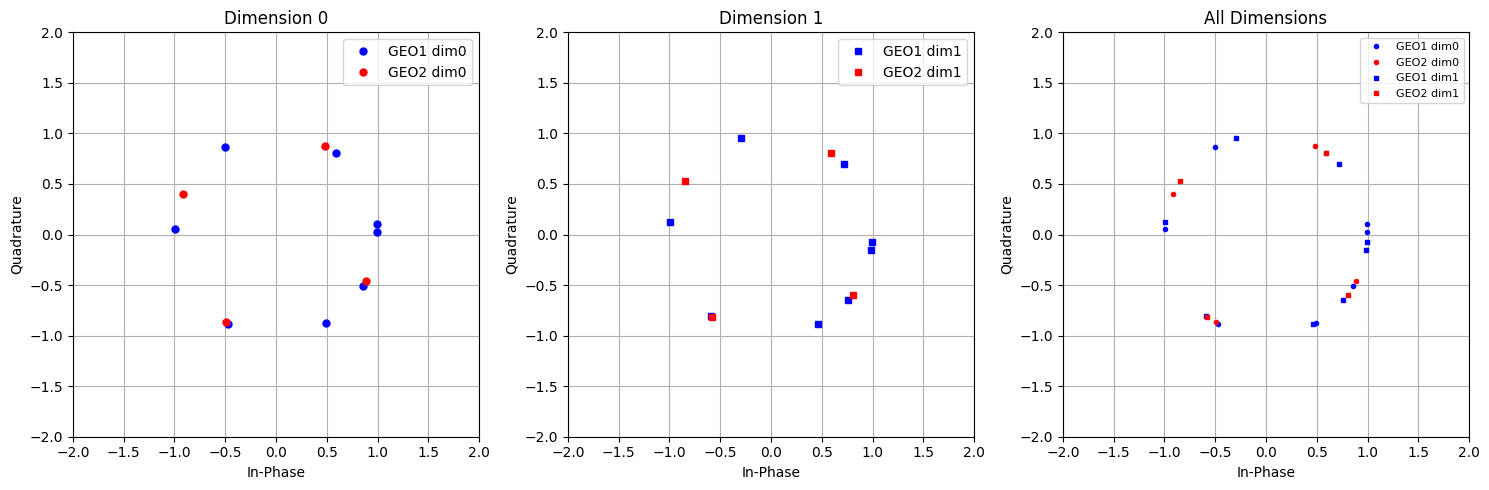

Epoch: 23/25, Loss(avg): 0.01861


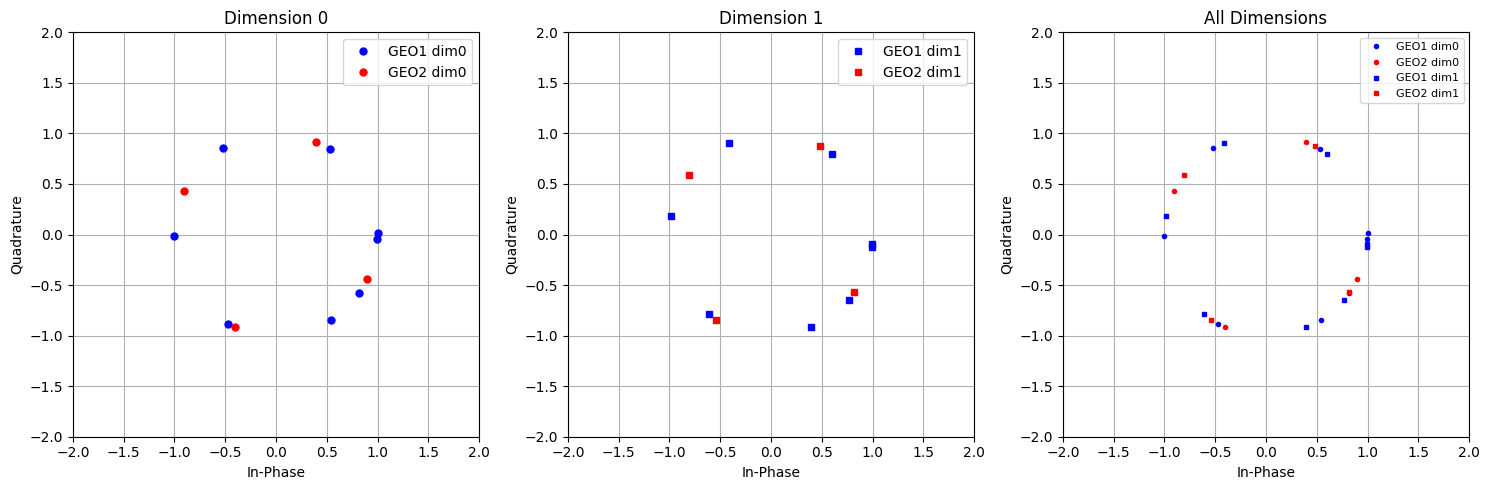

Epoch: 24/25, Loss(avg): 0.01947


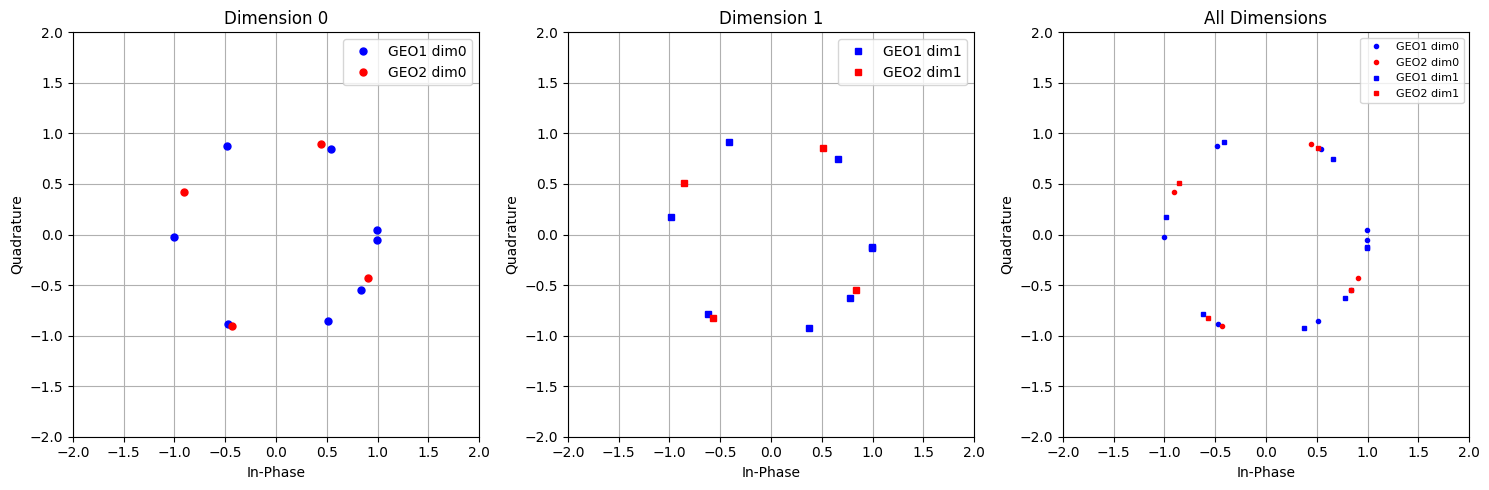

Epoch: 25/25, Loss(avg): 0.01823


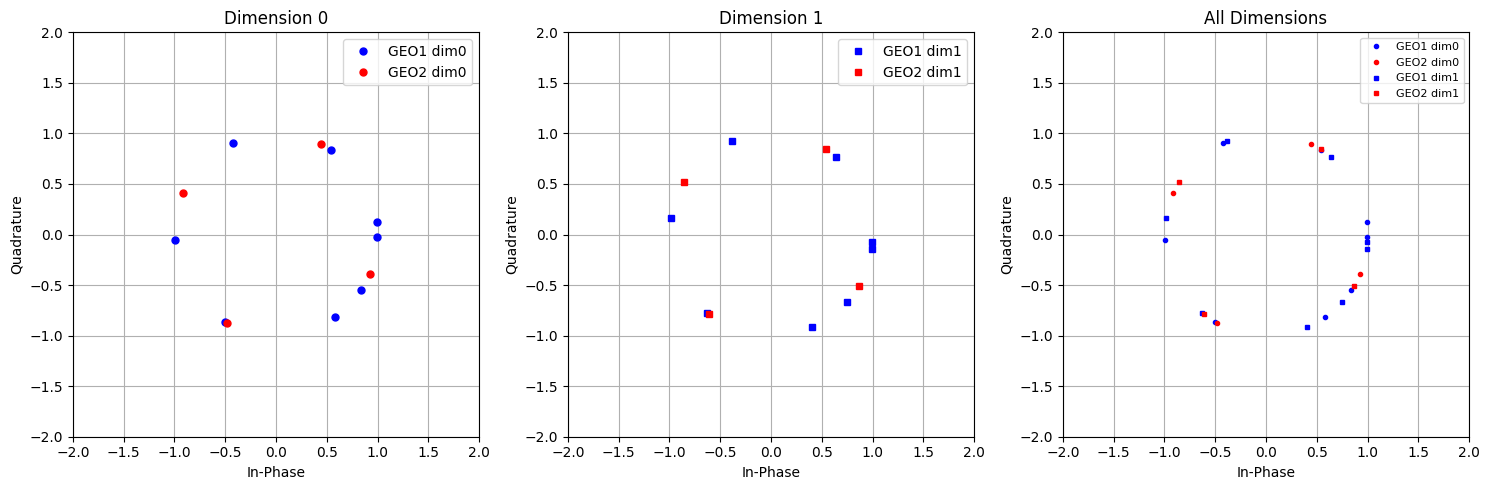

In [17]:
n_steps = len(data_oneH_1) // batch_size
optimizer = keras.optimizers.Nadam(learning_rate=0.006, clipnorm=1.0)
loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=0.0)
train_start(n_epochs, n_steps, plot_encoding = True, only_decoder = False, loss_fn=loss_fn, optimizer=optimizer)

In [18]:
SER_data_transmitter1, SER_data_transmitter2 = Test_AE(
    data_normal1, data_normal2, 
    SNR_range = np.linspace(0, 20, 11), 
    NOMA_SNR=NOMA_SNR
    )

**Ploting**

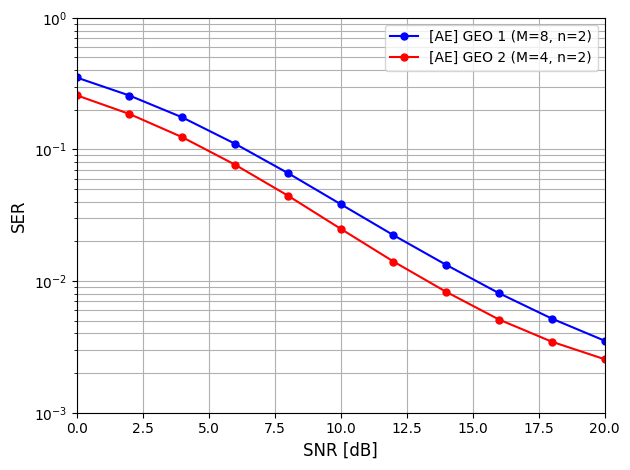

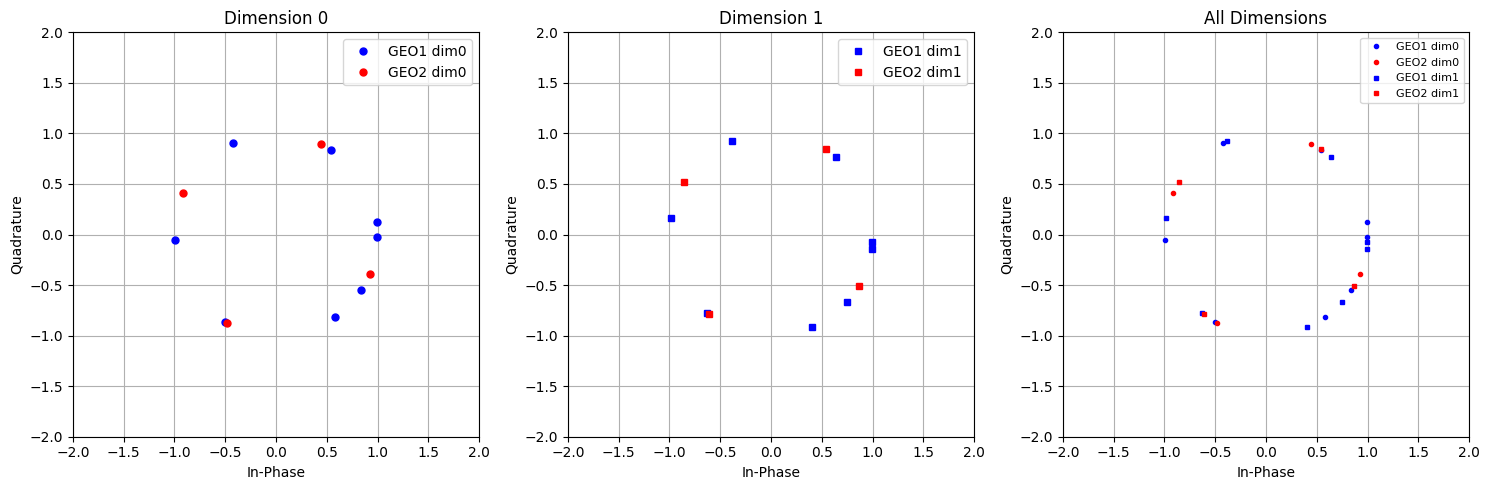

Saved combined constellation data to: /Users/scha/Library/CloudStorage/Dropbox/ICIS lab/research_24Seungcheol/manuscript-SC/[revision] IEEE Communications Letters (AE design)/revision-20260130/reply_letter/simulation_code/20260218/DataFile/20260218_AE_OGDim.csv
Saved SER csv to: /Users/scha/Library/CloudStorage/Dropbox/ICIS lab/research_24Seungcheol/manuscript-SC/[revision] IEEE Communications Letters (AE design)/revision-20260130/reply_letter/simulation_code/20260218/DataFile/20260218_AE_OG_SER.csv


In [20]:
# -----------------------------
# Plot & Save (Switch version)
# -----------------------------

# SER performance
SNR_db1, SER1_AE = SER_data_transmitter1
SNR_db2, SER2_AE = SER_data_transmitter2

LW=1.5; MS=5; FS=12

plt.figure()
plt.semilogy(SNR_db1, SER1_AE, 'b-o', linewidth=LW, markersize=MS, 
             label=f'[AE] GEO 1 (M={M1}, n={n1})')
plt.semilogy(SNR_db1, SER2_AE, 'r-o', linewidth=LW, markersize=MS, 
             label=f'[AE] GEO 2 (M={M2}, n={n2})')

plt.ylim(1e-3, 1)
plt.xlim(0, 20)
plt.xlabel('SNR [dB]', fontsize=FS)
plt.ylabel('SER', fontsize=FS)
plt.grid(True, which='both')
plt.legend(prop={'size':10}, loc='best')
plt.tight_layout()

Save = True

if Save == True:

    ## Save path
    path = r'/Users/scha/Library/CloudStorage/Dropbox/ICIS lab/research_24Seungcheol/manuscript-SC/[revision] IEEE Communications Letters (AE design)/revision-20260130/reply_letter/simulation_code/20260218/DataFile'
    
    tag1 = '20260218_AE'
    tag2 = 'OG'

    # SER Graph Save
    perf_graph_path = os.path.join(path, f"{tag1}_{tag2}_Graph.png")
    plt.savefig(perf_graph_path, dpi=300)

    # Constellation Save
    last_fig_path = os.path.join(path, f"{tag1}_{tag2}_Constellation.png")
    constellation_plot(M1, M2, n1, n2, save_path=last_fig_path)
    save_constellation_to_csv(encoder1_layer, encoder2_layer, M1, M2, n1, n2,path, tag1, tag2)

    # SER CSV Save
    df_raw = pd.DataFrame({
        'SER1_AE': SER1_AE,
        'SER2_AE': SER2_AE
    })

    csv_path = os.path.join(path, f"{tag1}_{tag2}_SER.csv")
    df_raw.round({'SER1_AE': 6, 'SER2_AE': 6}).to_csv(csv_path, index=False)

    print(f"Saved SER csv to: {csv_path}")
